# 03 - Reversible training pushed to the MAXIMUM batch size

**Goal (assignment part 3).** Take the winning reversible variant from notebook 02 and see how big a
batch a single GPU can hold now that activations are no longer stored. Train for 50M tokens at that
batch and compare with notebook 01.

Two things to watch for:
1. Reversibility removes the per-layer activations, but the **output logits** (`tokens x vocab`) still
   need memory. With a small model they become the limit. An optional *chunked loss* removes that limit.
2. A giant batch means **few optimizer steps** for the same 50M tokens. We scale the learning rate by
   `sqrt(batch/64)` and also run an un-scaled control so you can see the effect.

In [1]:
SMOKE = False   # True = tiny CPU version of this whole notebook (used to test the code; not for results)
REPO_URL = "https://github.com/pratik-2025/Asisgnment13_Reversible_LLM_20M"   # <- edit: only needed on Colab
USE_DRIVE = True   # True = keep data + results on Google Drive so they survive a Colab disconnect

import os, sys, copy, json, subprocess
if os.path.exists("../revlm"):
    os.chdir("..")                                   # opened from the notebooks/ folder
elif not os.path.exists("revlm"):
    assert "YOUR-USERNAME" not in REPO_URL, "edit REPO_URL (top of this cell) to point at your GitHub repo"
    subprocess.run(["git", "clone", REPO_URL, "repo"], check=True)   # fresh Colab VM
    os.chdir("repo")
sys.path.insert(0, os.getcwd())
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "tokenizers", "datasets"], check=False)

import torch
from IPython.display import Image, display
from revlm import selftest, experiment as ex
from revlm.bench import bench_steps, scaling_table
from revlm.data import prepare_data, Data
from revlm.report import write_summary, plot_scaling

S = ex.settings(SMOKE)
DEV = ex.device()
RESULTS = "results_smoke" if SMOKE else "results"
DATA_DIR = "data_smoke" if SMOKE else "data"
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS = "/content/drive/MyDrive/reversible-llm-20m/" + RESULTS
    DATA_DIR = "/content/drive/MyDrive/reversible-llm-20m/" + DATA_DIR
print("device:", DEV, torch.cuda.get_device_name() if DEV == "cuda" else "(no GPU!)" if not SMOKE else "(smoke test)")
if DEV != "cuda" and not SMOKE:
    print("WARNING: no GPU. In Colab use Runtime > Change runtime type > GPU.")

Mounted at /content/drive
device: cuda Tesla T4


## 0. Sanity check

In [2]:
# 30-second correctness check on THIS machine/GPU before spending an hour of compute.
assert selftest.main(DEV), "self-test failed - do not trust any numbers below"

device=cuda
1. params identical across modes: 53728


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


2. reconstruction max |error| (float64): {'midpoint': '4.4e-16', 'leapfrog': '8.9e-16', 'hamiltonian': '2.2e-16'}
3. memory-saving vs autograd (loss diff, worst rel. grad diff): {'midpoint': ('0.0e+00', '1.2e-15'), 'leapfrog': ('0.0e+00', '1.6e-15'), 'hamiltonian': ('0.0e+00', '9.5e-16')}
4. chunked vs normal loss (loss diff, rel. grad diff): {'baseline': ('8.9e-16', '4.1e-16'), 'midpoint': ('0.0e+00', '3.1e-16')}
4b. mixed-precision grad cosine(memory-saving, autograd): {'midpoint': '1.00000', 'leapfrog': '1.00000', 'hamiltonian': '1.00000'}
ALL CHECKS PASSED


## 1. Data

In [3]:
# Downloads TinyStories, trains an 8k BPE tokenizer, writes exactly 50M training tokens (~3-6 min, cached).
prepare_data(DATA_DIR, vocab_size=8192, **S["data"])
data = Data(DATA_DIR, S["model"].ctx, seed=1337)
print(f"train tokens available: {len(data.train):,}   validation tokens: {len(data.val):,}   sequences: {data.n_seq:,}")

train tokens available: 50,000,000   validation tokens: 1,000,000   sequences: 97,656


In [4]:
def mk(mode, **over):
    """20M-parameter model config in the given mode (same weights/shape for every mode)."""
    mc = copy.deepcopy(S["model"]); mc.mode = mode
    for k, v in over.items():
        setattr(mc, k, v)
    return mc

from revlm.model import GPT
print(f"parameters: {GPT(mk('baseline')).num_params()/1e6:.2f}M   (layers={S['model'].n_layer}, d_model={S['model'].d_model}, vocab={S['model'].vocab_size}, ctx={S['model'].ctx})")

parameters: 20.01M   (layers=14, d_model=320, vocab=8192, ctx=512)


In [5]:
B_FIXED = ex.load(RESULTS, "fixed_batch")["B_fixed"]
win = ex.load(RESULTS, "winner")
WINNER, H = win["winner"], win["h"]
print(f"winner: {WINNER} (h={H}); fixed batch from notebook 01: {B_FIXED}")

winner: leapfrog (h=0.5); fixed batch from notebook 01: 104


## 2. How large a batch fits?

In [6]:
s_plain = ex.search_or_load("maxbatch_rev_plainloss", mk(WINNER, h=H), RESULTS, S)
s_chunk = ex.search_or_load("maxbatch_rev_chunkedloss", mk(WINNER, h=H, loss_chunk=S["loss_chunk"]), RESULTS, S)
print("max batch, reversible:                ", s_plain["max_batch"])
print("max batch, reversible + chunked loss: ", s_chunk["max_batch"])

    B=    8  fits  peak      657 MiB
    B=   16  fits  peak     1045 MiB
    B=   32  fits  peak     1840 MiB
    B=   64  fits  peak     3424 MiB
    B=  128  fits  peak     6597 MiB
    B=  256  OOM 
    B=  192  fits  peak     9769 MiB
    B=  224  fits  peak    11356 MiB
    B=  240  OOM 
    B=  232  fits  peak    11755 MiB
[maxbatch_rev_plainloss] max batch = 232
    B=    8  fits  peak      657 MiB
    B=   16  fits  peak     1045 MiB
    B=   32  fits  peak     1100 MiB
    B=   64  fits  peak     1181 MiB
    B=  128  fits  peak     1957 MiB
    B=  256  fits  peak     3560 MiB
    B=  512  fits  peak     6769 MiB
    B= 1024  fits  peak    13186 MiB
    B= 2048  OOM 
    B= 1536  OOM 
    B= 1280  OOM 
    B= 1152  OOM 
    B= 1088  OOM 
    B= 1056  fits  peak    13589 MiB
    B= 1072  OOM 
    B= 1064  OOM 
[maxbatch_rev_chunkedloss] max batch = 1056
max batch, reversible:                 232
max batch, reversible + chunked loss:  1056


## 3. Speed and memory as the batch grows (reversible vs baseline where the baseline still fits)

In [7]:
ladder = sorted({B_FIXED, *[B_FIXED * k for k in (2, 3, 4, 6, 8) if B_FIXED * k <= s_chunk["max_batch"]],
                 s_plain["max_batch"], s_chunk["max_batch"]})
rows = []
for B in ladder:
    for name, mc in [("baseline", mk("baseline")), (WINNER, mk(WINNER, h=H)),
                     (WINNER + "+chunked_loss", mk(WINNER, h=H, loss_chunk=S["loss_chunk"]))]:
        r = bench_steps(mc, B, DEV, "auto", n_steps=4)
        rows.append(dict(name=name, B=B, **{k: r[k] for k in ("ok", "peak_mib", "tokens_per_sec")}))
        pk = f"{r['peak_mib']:8.0f}" if r["peak_mib"] else "     n/a"
        print(f"B={B:5d} {name:22s}", f"peak {pk} MiB  {r['tokens_per_sec']:9.0f} tok/s" if r["ok"] else "OOM")
ex.save(RESULTS, "batch_ladder", {"rows": rows})

B=  104 baseline               peak    13644 MiB      60710 tok/s
B=  104 leapfrog               peak     5409 MiB      44682 tok/s
B=  104 leapfrog+chunked_loss  peak     1658 MiB      43321 tok/s
B=  208 baseline               OOM
B=  208 leapfrog               peak    10563 MiB      45053 tok/s
B=  208 leapfrog+chunked_loss  peak     2969 MiB      43123 tok/s
B=  232 baseline               OOM
B=  232 leapfrog               peak    11755 MiB      44649 tok/s
B=  232 leapfrog+chunked_loss  peak     3263 MiB      42793 tok/s
B=  312 baseline               OOM
B=  312 leapfrog               OOM
B=  312 leapfrog+chunked_loss  peak     4269 MiB      43033 tok/s
B=  416 baseline               OOM
B=  416 leapfrog               OOM
B=  416 leapfrog+chunked_loss  peak     5563 MiB      43590 tok/s
B=  624 baseline               OOM
B=  624 leapfrog               OOM
B=  624 leapfrog+chunked_loss  peak     8173 MiB      43429 tok/s
B=  832 baseline               OOM
B=  832 leapfrog         

## 4. Train at the maximum batch size

In [8]:
use_chunk = s_chunk["max_batch"] > s_plain["max_batch"]
B_MAX = max(s_chunk["max_batch"], s_plain["max_batch"])
mc_max = mk(WINNER, h=H, loss_chunk=S["loss_chunk"] if use_chunk else 0)
print(f"training at B={B_MAX}, chunked loss = {use_chunk}")
r3 = ex.run_or_load(mc_max, ex.make_train_cfg(S, "03_rev_maxbatch", B_MAX), data, RESULTS)

training at B=1056, chunked loss = True
[03_rev_maxbatch] mode=leapfrog h=0.5 B=1056 steps=92 params=20.01M amp=torch.float16 lr_peak=2.00e-03
  step     1/92 tokens   0.54M loss 9.0548     23741 tok/s mem   13435 MiB
  >> val loss 6.2425 at 4.9M tokens
  >> val loss 5.7060 at 9.7M tokens
  step    21/92 tokens  11.35M loss 6.5288     45405 tok/s mem   13591 MiB
  >> val loss 5.5865 at 14.6M tokens
  >> val loss 5.4783 at 19.5M tokens
  step    41/92 tokens  22.17M loss 5.5114     44860 tok/s mem   13591 MiB
  >> val loss 5.3564 at 24.3M tokens
  >> val loss 5.2330 at 29.2M tokens
  step    61/92 tokens  32.98M loss 5.2389     44441 tok/s mem   13591 MiB
  >> val loss 5.0778 at 34.1M tokens
  >> val loss 4.9082 at 38.9M tokens
  step    81/92 tokens  43.79M loss 4.8996     44162 tok/s mem   13591 MiB
  >> val loss 4.7892 at 43.8M tokens
  >> val loss 4.7112 at 48.7M tokens
  step    92/92 tokens  49.74M loss 4.7565     44319 tok/s mem   13591 MiB
  >> val loss 4.6963 at 49.7M tokens
[0

Control: the same run with the learning rate NOT scaled up for the bigger batch.

In [9]:
RUN_LR_CONTROL = True
if RUN_LR_CONTROL:
    r3b = ex.run_or_load(mc_max, ex.make_train_cfg(S, "03_rev_maxbatch_lr_unscaled", r3["batch_size"], lr_scaling="none"), data, RESULTS)

[03_rev_maxbatch_lr_unscaled] mode=leapfrog h=0.5 B=1056 steps=92 params=20.01M amp=torch.float16 lr_peak=1.00e-03
  step     1/92 tokens   0.54M loss 9.0548     43089 tok/s mem   13432 MiB
[03_rev_maxbatch_lr_unscaled] OOM at B=1056; retrying with B=1048
[03_rev_maxbatch_lr_unscaled] mode=leapfrog h=0.5 B=1048 steps=93 params=20.01M amp=torch.float16 lr_peak=1.00e-03
  step     1/93 tokens   0.54M loss 9.0548     43264 tok/s mem   13331 MiB
  >> val loss 6.7977 at 4.8M tokens
  >> val loss 5.3534 at 9.7M tokens
  step    21/93 tokens  11.27M loss 6.5955     44101 tok/s mem   13489 MiB
  >> val loss 4.7458 at 14.5M tokens
  >> val loss 4.4230 at 19.3M tokens
  step    41/93 tokens  22.00M loss 4.6097     43927 tok/s mem   13489 MiB
  >> val loss 4.2384 at 24.1M tokens
  >> val loss 4.1249 at 29.0M tokens
  step    61/93 tokens  32.73M loss 4.1350     43819 tok/s mem   13489 MiB
  >> val loss 4.0535 at 33.8M tokens
  >> val loss 4.0053 at 38.6M tokens
  step    81/93 tokens  43.46M loss

## 5. Final report
`PRICE_PER_HOUR` is **your assumption** for what one hour of this GPU costs on a cloud provider
(Colab free = $0). It only feeds the last column - edit it before quoting cost numbers.

| run | mode | batch | steps | tokens seen | final train loss | final val loss | tokens/s (median) | peak mem (GiB) | wall time (min) | est. cost ($) |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 01_baseline | baseline | 104 | 939 | 50.0M | 2.1417 | 2.1885 | 62,963 | 13.32 | 14.2 | 0.08 |
| 02_hamiltonian | hamiltonian | 104 | 939 | 50.0M | 2.3914 | 2.4389 | 51,615 | 5.28 | 17.1 | 0.10 |
| 02_leapfrog | leapfrog | 104 | 939 | 50.0M | 2.0984 | 2.1478 | 47,812 | 5.28 | 18.5 | 0.11 |
| 02_midpoint | midpoint | 104 | 939 | 50.0M | 2.2606 | 2.3055 | 50,283 | 5.28 | 17.8 | 0.10 |
| 03_rev_maxbatch | leapfrog | 1056 | 92 | 49.7M | 4.9845 | 4.6963 | 44,572 | 13.27 | 19.8 | 0.12 |
| 03_rev_maxbatch_lr_unscaled | leapfrog | 1048 | 93 | 49.9M | 4.0121 | 3.9478 | 43,753 | 13.17 | 20.1 | 0.12 |


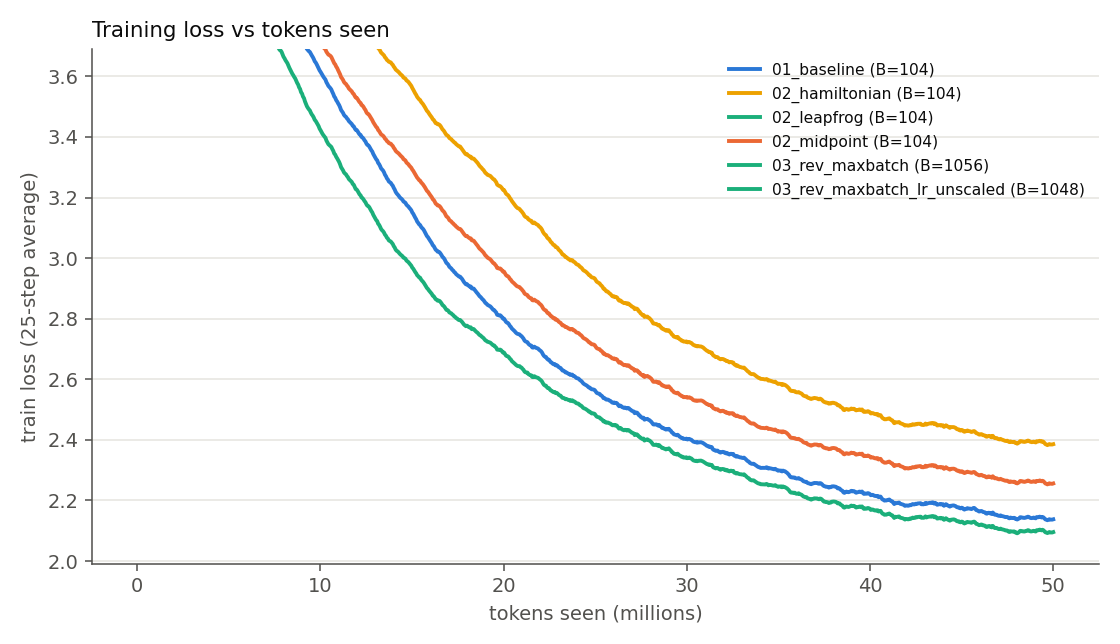

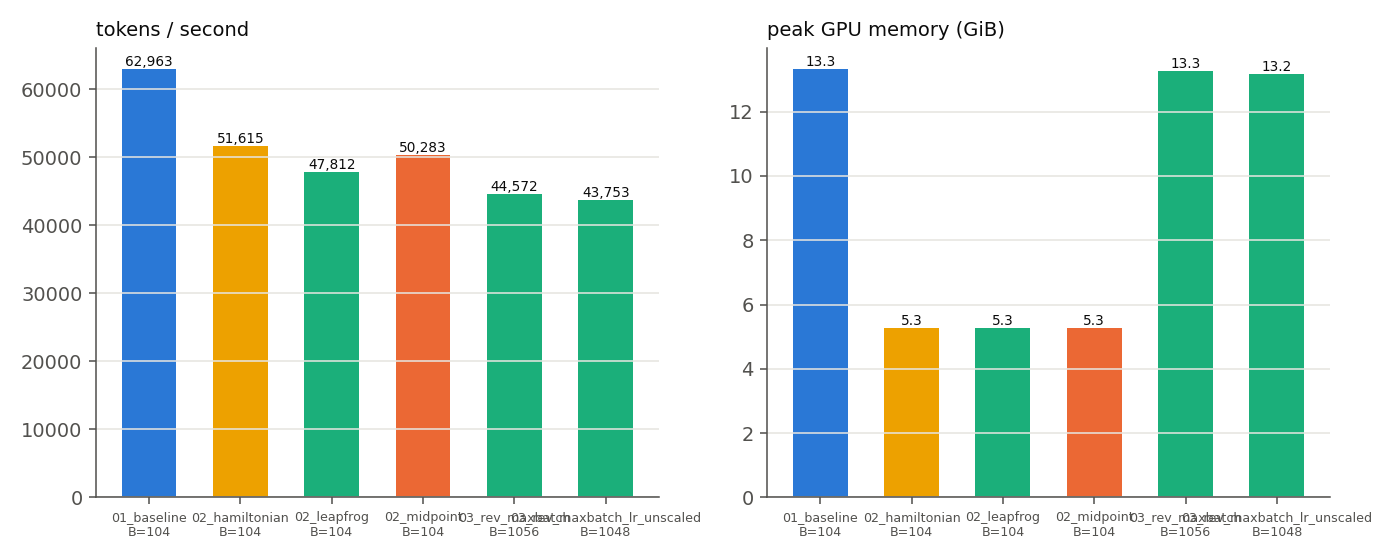

| run | mode | batch | steps | tokens seen | final train loss | final val loss | tokens/s (median) | peak mem (GiB) | wall time (min) | est. cost ($) |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 01_baseline | baseline | 104 | 939 | 50.0M | 2.1417 | 2.1885 | 62,963 | 13.32 | 14.2 | 0.08 |
| 02_hamiltonian | hamiltonian | 104 | 939 | 50.0M | 2.3914 | 2.4389 | 51,615 | 5.28 | 17.1 | 0.10 |
| 02_leapfrog | leapfrog | 104 | 939 | 50.0M | 2.0984 | 2.1478 | 47,812 | 5.28 | 18.5 | 0.11 |
| 02_midpoint | midpoint | 104 | 939 | 50.0M | 2.2606 | 2.3055 | 50,283 | 5.28 | 17.8 | 0.10 |
| 03_rev_maxbatch | leapfrog | 1056 | 92 | 49.7M | 4.9845 | 4.6963 | 44,572 | 13.27 | 19.8 | 0.12 |
| 03_rev_maxbatch_lr_unscaled | leapfrog | 1048 | 93 | 49.9M | 4.0121 | 3.9478 | 43,753 | 13.17 | 20.1 | 0.12 |



In [10]:
PRICE_PER_HOUR = 0.35     # assumption - edit
write_summary(RESULTS, price_per_hour=PRICE_PER_HOUR)
display(Image(f"{RESULTS}/loss_curves.png")); display(Image(f"{RESULTS}/speed_memory.png"))
print(open(f"{RESULTS}/summary.md").read())